In [2]:
"""
Business Problem:
Banks face financial risk when approving loans to customers
who may default. Approving risky applicants leads to financial
loss, while rejecting eligible customers leads to lost revenue.

Objective:
Build a machine learning model to predict loan approval
based on applicant financial and demographic features.

Type: Supervised Learning (Binary Classification)
Target:
    1 -> Loan Approved
    0 -> Loan Rejected

"""

'\nBusiness Problem:\nBanks face financial risk when approving loans to customers\nwho may default. Approving risky applicants leads to financial\nloss, while rejecting eligible customers leads to lost revenue.\n\nObjective:\nBuild a machine learning model to predict loan approval\nbased on applicant financial and demographic features.\n\nType: Supervised Learning (Binary Classification)\nTarget:\n    1 -> Loan Approved\n    0 -> Loan Rejected\n\n'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [6]:
#Loading Dataset
df= pd.read_csv("loan_prediction.csv")

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (614, 13)

Missing Values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [7]:
#Data Cleaning

# Drop irrelevant column
df.drop(columns=['Loan_ID'], inplace=True)

# Encode target variable
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Handle missing categorical values (mode)
categorical_cols = ['Gender', 'Married', 'Dependents',
                    'Self_Employed', 'Loan_Amount_Term',
                    'Credit_History']

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Handle missing numeric values (median)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

C:\Users\VINIT DAVE\AppData\Local\Temp\ipykernel_10068\3694183867.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\VINIT DAVE\AppData\Local\Temp\ipykernel_10068\3694183867.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a cop

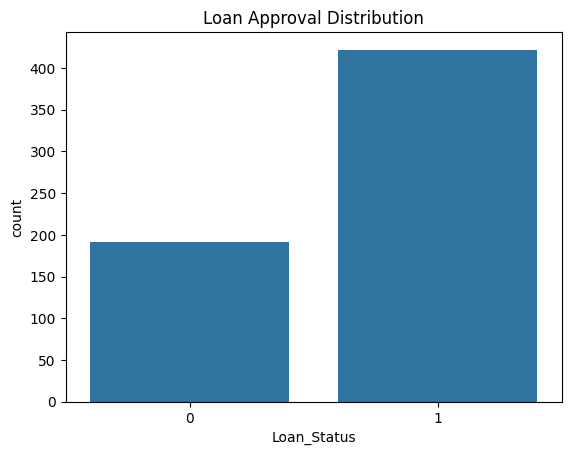

In [8]:
#Exploratory Data Analysis

# Target Distribution
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()



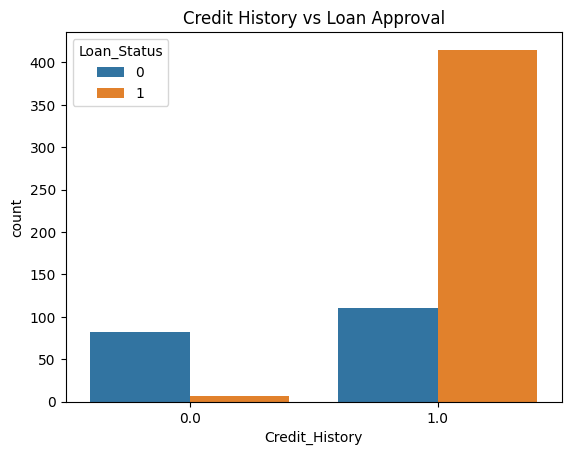

In [9]:
# Credit History vs Loan Status
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title("Credit History vs Loan Approval")
plt.show()

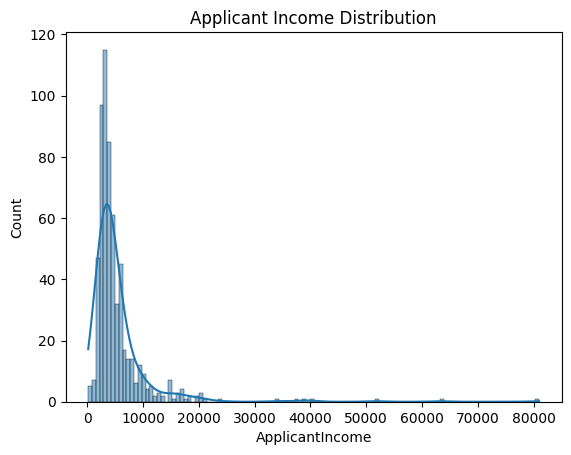

In [10]:
# Income Distribution
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

In [11]:
#Feature Engineering
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Income_to_Loan_Ratio'] = df['TotalIncome'] / df['LoanAmount']
df['Is_High_Loan'] = (df['LoanAmount'] > df['LoanAmount'].median()).astype(int)

In [12]:
#Convert Categorical Variables
df = pd.get_dummies(df, drop_first=True)

In [21]:
#Train-Test Split
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
#Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
#Model Training

# Logistic Regression 
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)


# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)


# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [16]:
#Evaluation Function

def evaluate_model(name, y_true, y_pred):
    print(f"\n========== {name} ==========")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))

evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Random Forest", y_test, rf_pred)



========== Logistic Regression ==========
Accuracy : 0.8617886178861789
Precision: 0.84
Recall   : 0.9882352941176471
F1 Score : 0.9081081081081082
Confusion Matrix:
 [[22 16]
 [ 1 84]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


========== Decision Tree ==========
Accuracy : 0.8455284552845529
Precision: 0.84375
Recall   : 0.9529411764705882
F1 Score : 0.8950276243093923
Confusion Matrix:
 [[23 15]
 [ 4 81]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.61      0.71        38
           1       0.84      0.95      0.90        85

    accuracy                           0.85       123
   macro avg       0.85      0.78 

In [17]:
#Cross Validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='f1')
print("\nRandom Forest Cross Validation F1 Scores:", cv_scores)
print("Average F1 Score:", cv_scores.mean())



Random Forest Cross Validation F1 Scores: [0.84353741 0.85135135 0.8707483  0.83783784 0.84      ]
Average F1 Score: 0.8486949806949807


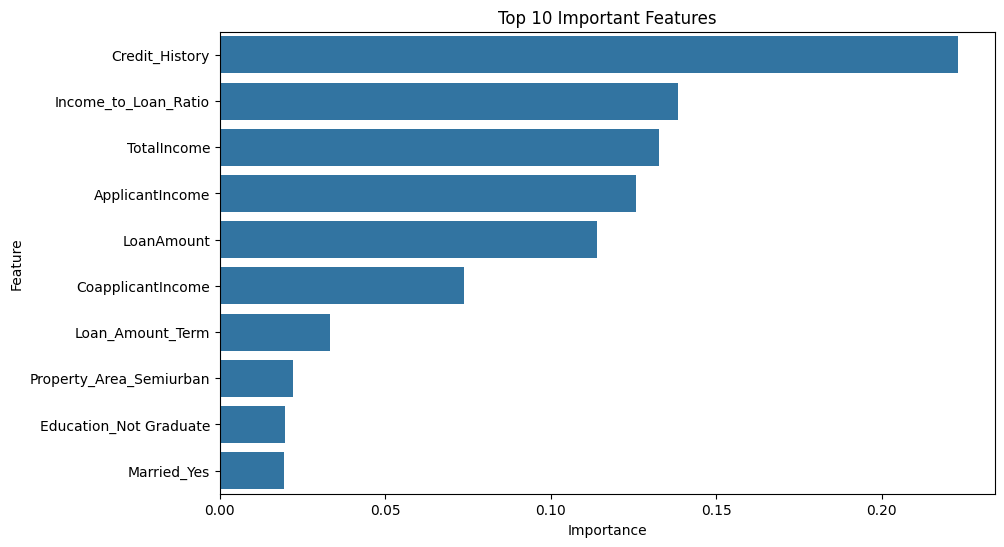

In [18]:
# Feature Importance
importances = rf.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature',
            data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [25]:
#Saving Model & Scaler
joblib.dump(rf, "loan_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel and scaler saved successfully!")


Model and scaler saved successfully!


In [19]:
print(X_train.columns)
print(len(X_train.columns))



AttributeError: 'numpy.ndarray' object has no attribute 'columns'